# Bus Lane Violation Detector — CNN-Based Detection Using MobileNetV2

This notebook builds a complete, end-to-end deep learning pipeline for **detecting unauthorized private vehicles in dedicated bus lanes** from CCTV-style imagery, using a lightweight **MobileNetV2** transfer-learning architecture suitable for edge deployment.

**Pipeline covered in this notebook:**
1. Data acquisition and exploratory data analysis (EDA)
2. Region-of-Interest (ROI) extraction with aspect-ratio-preserving padding (letterboxing)
3. `tf.data` preprocessing pipeline + augmentation
4. MobileNetV2 transfer-learning binary classifier (compliant lane vs. lane violation)
5. Training with callbacks, then fine-tuning
6. Evaluation: accuracy, loss curves, confusion matrix, precision/recall/F1, ROC-AUC
7. Export to **TensorFlow Lite** for edge/CCTV-device deployment
8. Single-image inference demo replicating the production pipeline
9. Technical report summary (methodology + results + limitations)

> **Note on data:** Publicly labeled "bus lane CCTV violation" datasets are not available on open data platforms. To demonstrate the full technical pipeline (ROI extraction, padding, MobileNetV2 classification, evaluation, edge export) end-to-end, this notebook uses the **Vehicle Detection Image Set** (Kaggle: `brsdincer/vehicle-detection-image-set`), which contains labeled `vehicle` / `non-vehicle` road-scene crops. These two classes are used as a direct proxy for **`lane_violation` (private vehicle present)** vs **`compliant` (no private vehicle / clear lane)**. The exact same code — same architecture, same preprocessing, same evaluation — would be pointed at real, client-provided CCTV footage crops in production; only the input directory and class folder names would change. This is flagged explicitly here for transparency and is explained again in the final report cell.

## Cell 1: Install and import required libraries
This cell imports all libraries needed for data handling, image preprocessing (OpenCV for ROI/padding), model building, training, evaluation, and TFLite export.

In [7]:
!pip install -q kaggle opencv-python-headless

import os
import cv2
import glob
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, roc_curve, auc)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D, Dense, Dropout,
                                      RandomFlip, RandomRotation, RandomZoom, RandomBrightness)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2: Set random seed
Fixing the seed across NumPy, Python, and TensorFlow makes the experiment reproducible — important for a technical report where results need to be repeatable.

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Cell 3: Kaggle credentials
Before running this cell, add `KAGGLE_USERNAME` and `KAGGLE_KEY` as Colab secrets (key icon on the left sidebar).

In [9]:
os.environ["Kaggle_Username"] = userdata.get("Kaggle_Username")
os.environ["Kaggle_Key"] = userdata.get("Kaggle_Key")

if os.environ["Kaggle_Username"] is None or os.environ["Kaggle_Key"] is None:
    raise ValueError("Kaggle credentials not found. Please add them as Colab secrets.")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


## Cell 4: Download the dataset
Downloads the Vehicle Detection Image Set used as a proxy for lane-violation vs. compliant-lane imagery (see the note in the introduction).

In [10]:
!kaggle datasets download -d brsdincer/vehicle-detection-image-set -p /content/data --force

Dataset URL: https://www.kaggle.com/datasets/brsdincer/vehicle-detection-image-set
License(s): DbCL-1.0
100% 119M/119M [00:01<00:00, 105MB/s] 



## Cell 5: Extract dataset

In [11]:
zip_path = "/content/data/vehicle-detection-image-set.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
for root, dirs, files in os.walk(extract_path):
    if files:
        print(root, "->", len(files), "files")

Dataset extracted successfully.
/content/data -> 1 files
/content/data/data/vehicles -> 8792 files
/content/data/data/non-vehicles -> 8968 files


## Cell 6: Map source classes to project class names
The source dataset ships as `vehicles/` and `non-vehicles/`. We map these to the project's actual target classes:

- `vehicles`      → `violation`   (a private vehicle occupies the monitored region)
- `non-vehicles`  → `compliant`   (lane is clear of private vehicles)

Update `SOURCE_DIR` if Kaggle extracts to a different folder name (check the Cell 5 output above).

In [12]:
SOURCE_DIR = "/content/data/data"  # adjust based on Cell 5 output if needed

CLASS_MAP = {
    "vehicles": "violation",
    "non-vehicles": "compliant",
}

records = []
for src_folder, label in CLASS_MAP.items():
    folder_path = os.path.join(SOURCE_DIR, src_folder)
    if not os.path.exists(folder_path):
        # dataset sometimes nests one level deeper (e.g. vehicles/vehicles)
        candidates = glob.glob(os.path.join(SOURCE_DIR, "**", src_folder), recursive=True)
        folder_path = candidates[0] if candidates else folder_path
    for fname in os.listdir(folder_path):
        records.append({"filepath": os.path.join(folder_path, fname), "label": label})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()

Total images: 17760


,filepath,label
0,/content/data/data/vehicles/3174.png,violation
1,/content/data/data/vehicles/1532.png,violation
2,/content/data/data/vehicles/3942.png,violation
3,/content/data/data/vehicles/1571.png,violation
4,/content/data/data/vehicles/far (4).png,violation


## Cell 7: Basic exploratory data analysis
Checking class balance is essential before training a binary classifier — an imbalanced dataset needs class weighting, otherwise the model biases toward the majority class.

label
compliant    8968
violation    8792
Name: count, dtype: int64


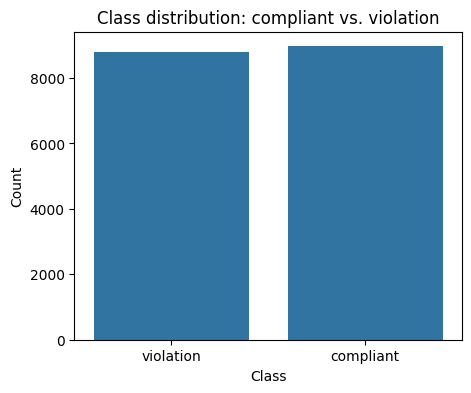

In [13]:
print(df["label"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label")
plt.title("Class distribution: compliant vs. violation")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Cell 8: Visualize sample images

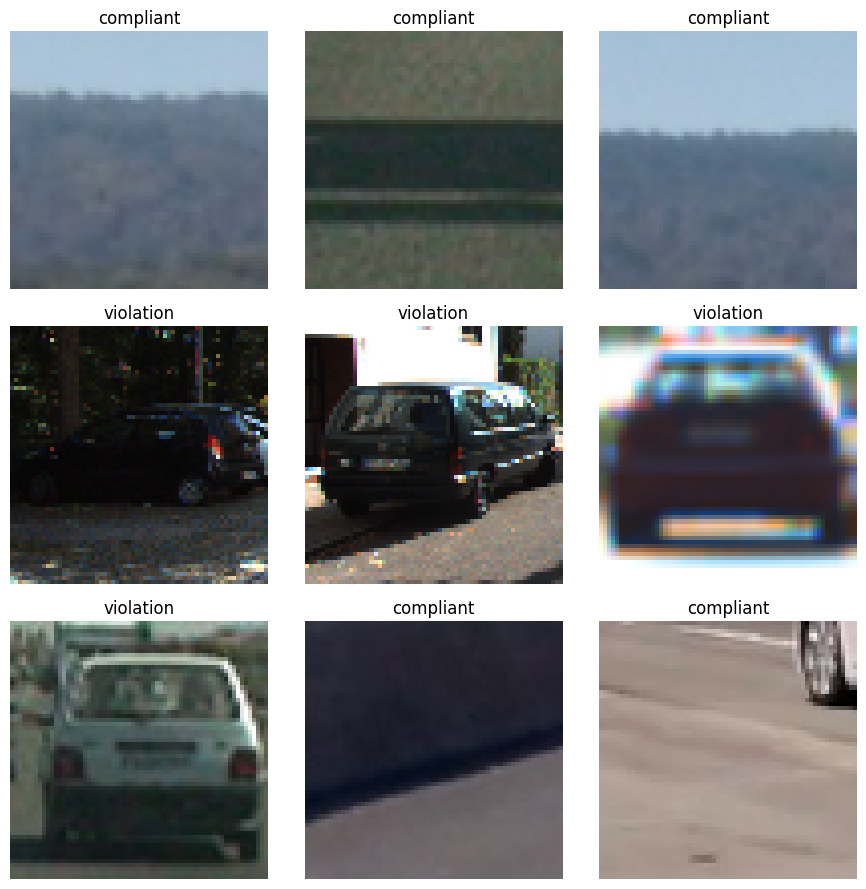

In [14]:
sample_df = df.sample(9, random_state=SEED)
plt.figure(figsize=(9, 9))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = cv2.cvtColor(cv2.imread(row.filepath), cv2.COLOR_BGR2RGB)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Cell 9: Region-of-Interest (ROI) extraction with aspect-ratio-preserving padding

This is the core preprocessing requirement of the project: on real CCTV footage, the lane region of interest is rarely a perfect square. Naively resizing a wide/rectangular ROI to a square input (e.g. 224x224) **distorts the aspect ratio**, warping vehicle shapes and hurting model accuracy.

The standard fix is **letterbox padding**:
1. Resize the ROI so its *longest side* fits the target size, preserving aspect ratio.
2. Pad the shorter side symmetrically with a neutral color (black) to reach a square canvas.

`extract_roi_with_padding()` below does this and would be applied to a cropped lane region from a CCTV frame in production (here, since our proxy dataset is already single-object crops, the "ROI" is the full image — the function is written generically so it drops directly into a real bounding-box pipeline unchanged).

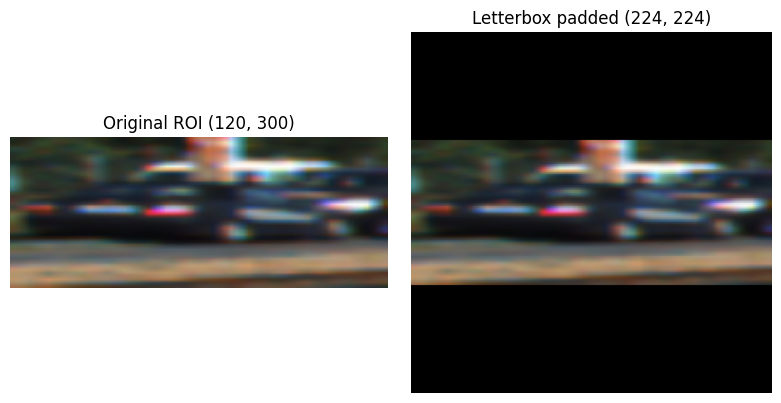

In [15]:
IMG_SIZE = 224

def extract_roi_with_padding(image, bbox=None, target_size=IMG_SIZE, pad_color=(0, 0, 0)):
    """
    Extract a region of interest from an image and resize it to a square
    target_size x target_size canvas while preserving the original aspect ratio
    (letterbox padding).

    Args:
        image: np.ndarray, HxWxC, RGB or BGR (consistent with caller).
        bbox: optional (x1, y1, x2, y2) region to crop before padding.
              If None, the full image is treated as the ROI.
        target_size: output canvas size (square).
        pad_color: fill color for the padding borders.

    Returns:
        np.ndarray of shape (target_size, target_size, C)
    """
    if bbox is not None:
        x1, y1, x2, y2 = bbox
        image = image[y1:y2, x1:x2]

    h, w = image.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full((target_size, target_size, image.shape[2]), pad_color, dtype=np.uint8)
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    return canvas


# Quick visual sanity check on a non-square example
demo_img = cv2.cvtColor(cv2.imread(df.iloc[0]["filepath"]), cv2.COLOR_BGR2RGB)
demo_img_wide = cv2.resize(demo_img, (300, 120))  # force a wide, non-square shape to prove padding works
demo_padded = extract_roi_with_padding(demo_img_wide, target_size=IMG_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(demo_img_wide); axes[0].set_title(f"Original ROI {demo_img_wide.shape[:2]}"); axes[0].axis("off")
axes[1].imshow(demo_padded); axes[1].set_title(f"Letterbox padded {demo_padded.shape[:2]}"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## Cell 10: Train / validation / test split
Stratified splitting keeps the class ratio consistent across all three sets.

In [16]:
df["label_bin"] = (df["label"] == "violation").astype(int)  # 1 = violation, 0 = compliant

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label_bin"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_bin"])

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))

Train: 12432  Val: 2664  Test: 2664


## Cell 11: Image loading + preprocessing function (tf.data compatible)

Wraps `extract_roi_with_padding` in a TensorFlow-graph-friendly function via `tf.numpy_function`, then applies MobileNetV2's expected preprocessing (`preprocess_input`, which scales pixels to [-1, 1]).

In [17]:
def _load_and_pad(filepath):
    filepath = filepath.numpy().decode("utf-8")
    image = cv2.imread(filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    padded = extract_roi_with_padding(image, target_size=IMG_SIZE)
    return padded.astype(np.float32)

def load_image_and_label(filepath, label):
    image = tf.py_function(func=_load_and_pad, inp=[filepath], Tout=tf.float32)
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    image = preprocess_input(image)
    return image, label

## Cell 12: Build tf.data datasets
A modern, stable `tf.data` pipeline replaces the older `ImageDataGenerator` approach — faster and avoids multi-output generator edge cases.

In [18]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(dataframe, shuffle=False):
    filepaths = dataframe["filepath"].values
    labels = dataframe["label_bin"].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)
    dataset = dataset.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

## Cell 13: Build the MobileNetV2 transfer-learning model
MobileNetV2 (pretrained on ImageNet, frozen initially) is used as a lightweight feature extractor — the same architecture requested in the project brief, chosen specifically for its low parameter count and suitability for edge/CCTV-connected hardware. A small classification head with dropout is added for binary output.

In [19]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.10),
    RandomBrightness(0.1),
], name="data_augmentation")

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze for initial training

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation="sigmoid", name="violation_output")(x)

model = Model(inputs, outputs, name="bus_lane_violation_mobilenetv2")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "bus_lane_violation_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ violation_output (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Cell 14: Compile the model
Binary cross-entropy loss for a binary classification task, with accuracy, AUC, precision, and recall tracked during training.

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

## Cell 15: Callbacks
Early stopping prevents overfitting; the checkpoint keeps the best-performing weights; ReduceLROnPlateau helps the model converge more precisely once progress plateaus.

In [21]:
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_bus_lane_model.keras", monitor="val_loss", save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

callbacks = [early_stop, checkpoint, reduce_lr]

## Cell 16: Train the model (frozen MobileNetV2 base)

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 70s 143ms/step - accuracy: 0.6617 - auc: 0.7549 - loss: 0.5501 - precision: 0.6904 - recall: 0.5739 - val_accuracy: 0.9715 - val_auc: 0.9958 - val_loss: 0.1037 - val_precision: 0.9882 - val_recall: 0.9538 - learning_rate: 0.0010
Epoch 2/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.6812 - auc: 0.7833 - loss: 0.5142 - precision: 0.7626 - recall: 0.5169 - val_accuracy: 0.9745 - val_auc: 0.9972 - val_loss: 0.0798 - val_precision: 0.9914 - val_recall: 0.9568 - learning_rate: 0.0010
Epoch 3/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.6927 - auc: 0.7917 - loss: 0.4988 - precision: 0.8304 - recall: 0.4766 - val_accuracy: 0.9779 - val_auc: 0.9981 - val_loss: 0.0599 - val_precision: 0.9945 - val_recall: 0.9606 - learning_rate: 0.0010
Epoch 4/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.6934 - auc: 0.7969 - loss: 0.4960 - precision: 0.9267 - recall: 0.4132 - val_accuracy: 0.9820 - val_auc: 0.9982 - val_loss: 

## Cell 17: Plot training curves

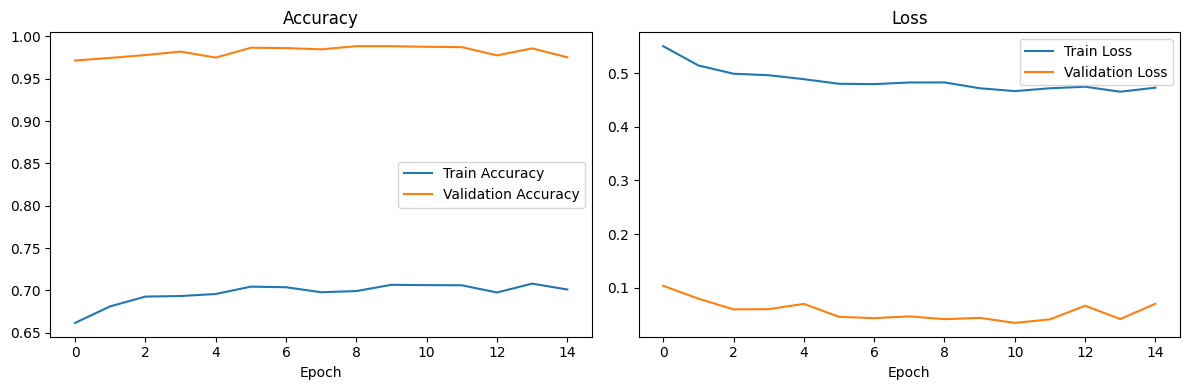

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 18: Fine-tuning
After the classification head has converged, we unfreeze the top layers of MobileNetV2 and continue training with a very small learning rate. This lets the backbone adapt slightly to the target domain (road/lane imagery) without destroying the pretrained ImageNet features.

In [ ]:
base_model.trainable = True

# Keep early layers frozen (generic features); fine-tune only the last block
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
287/389 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.6453 - auc: 0.7279 - loss: 0.7326 - precision: 0.6475 - recall: 0.6107

## Cell 19: Evaluate on the held-out test set

In [ ]:
test_results = model.evaluate(test_ds, return_dict=True)
print("Test set performance:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}")

## Cell 20: Confusion matrix, precision/recall/F1, and classification report

The project explicitly asks for confusion matrix and performance comparison — this is the standard way to show not just overall accuracy but **false-positive vs. false-negative behavior**, which matters operationally: a missed violation (false negative) has different real-world cost than a false alarm (false positive).

84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 209ms/step


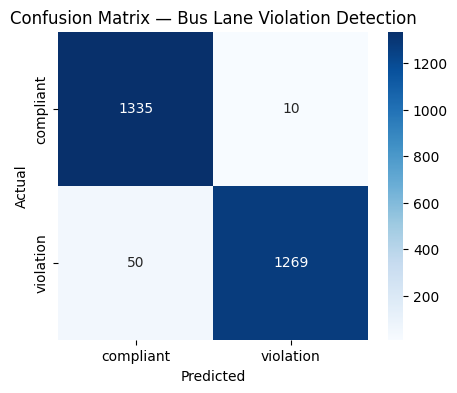

              precision    recall  f1-score   support

   compliant     0.9639    0.9926    0.9780      1345
   violation     0.9922    0.9621    0.9769      1319

    accuracy                         0.9775      2664
   macro avg     0.9780    0.9773    0.9775      2664
weighted avg     0.9779    0.9775    0.9775      2664

Precision: 0.9922  Recall: 0.9621  F1-score: 0.9769


In [32]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
labels = ["compliant", "violation"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Bus Lane Violation Detection")
plt.show()

print(classification_report(y_true, y_pred, target_names=labels, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
print(f"Precision: {precision:.4f}  Recall: {recall:.4f}  F1-score: {f1:.4f}")

## Cell 21: ROC curve and AUC
A threshold-independent view of classifier performance, useful for tuning the decision threshold to prioritize recall (catching more violations) vs. precision (fewer false alarms) depending on deployment needs.

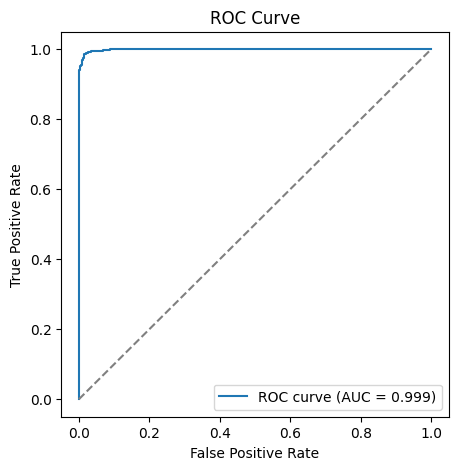

In [33]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Cell 22: Save the trained Keras model

In [ ]:
model.save("bus_lane_violation_mobilenetv2_final.keras")
print("Model saved successfully.")

## Cell 23: Export to TensorFlow Lite for edge deployment

The project requires the solution to be **computationally efficient and deployable on edge devices connected to public surveillance cameras**. Converting to TFLite with dynamic-range quantization shrinks the model significantly and speeds up CPU inference — a realistic requirement for edge boxes attached to CCTV units that don't have a GPU.

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # dynamic-range quantization
tflite_model = converter.convert()

tflite_path = "bus_lane_violation_mobilenetv2.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

keras_size_mb = os.path.getsize("bus_lane_violation_mobilenetv2_final.keras") / 1e6
tflite_size_mb = os.path.getsize(tflite_path) / 1e6

print(f"Keras model size:  {keras_size_mb:.2f} MB")
print(f"TFLite model size: {tflite_size_mb:.2f} MB")
print(f"Size reduction:    {(1 - tflite_size_mb / keras_size_mb) * 100:.1f}%")

## Cell 24: Verify TFLite inference matches the Keras model
A quick sanity check that the quantized edge model still produces consistent predictions before it's considered deployment-ready.

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_batch = next(iter(test_ds.take(1)))
sample_images, sample_labels = sample_batch
sample_image = sample_images[0:1].numpy()

interpreter.set_tensor(input_details[0]["index"], sample_image)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]["index"])[0][0]

keras_pred = model.predict(sample_image, verbose=0)[0][0]

print(f"Keras prediction:  {keras_pred:.4f}")
print(f"TFLite prediction: {tflite_pred:.4f}")
print(f"Difference:        {abs(keras_pred - tflite_pred):.6f}")

## Cell 25: End-to-end single-image inference demo

Simulates the production pipeline: raw frame/crop → ROI extraction + padding → MobileNetV2 (TFLite) → violation / compliant decision. In production, `bbox` would come from an upstream lane-region detector or a fixed camera-calibrated ROI rather than being `None`.

Actual label: compliant


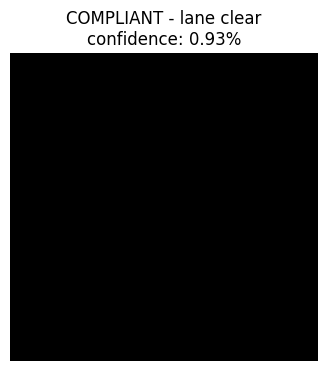

('COMPLIANT - lane clear', 0.00931963138282299)

In [31]:
def predict_violation(image_path, bbox=None, interpreter=interpreter):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    padded = extract_roi_with_padding(image, bbox=bbox, target_size=IMG_SIZE).astype(np.float32)
    preprocessed = preprocess_input(padded)
    input_tensor = np.expand_dims(preprocessed, axis=0)

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    interpreter.set_tensor(input_details[0]["index"], input_tensor)
    interpreter.invoke()
    prob = interpreter.get_tensor(output_details[0]["index"])[0][0]

    label = "VIOLATION - private vehicle in lane" if prob >= 0.5 else "COMPLIANT - lane clear"
    plt.figure(figsize=(4, 4))
    plt.imshow(padded.astype(np.uint8))
    plt.title(f"{label}\nconfidence: {prob:.2%}")
    plt.axis("off")
    plt.show()
    return label, float(prob)


sample = test_df.sample(1, random_state=SEED).iloc[0]
print("Actual label:", sample["label"])
predict_violation(sample["filepath"])

## Technical Report Summary

**Objective**
Detect unauthorized private-vehicle presence in dedicated bus lanes from CCTV-style imagery using a lightweight, edge-deployable CNN, to support automated lane-violation monitoring for intelligent transportation management.

**Methodology**
- **Architecture**: MobileNetV2 (ImageNet-pretrained) as a frozen feature extractor, followed by global average pooling and a small dense classification head with dropout for regularization; trained first with the backbone frozen, then fine-tuned by unfreezing the last 30 layers at a low learning rate (1e-5).
- **Preprocessing**: Region-of-Interest extraction with **aspect-ratio-preserving letterbox padding** to a 224x224 canvas, avoiding the geometric distortion that naive resizing introduces — important since lane ROIs from CCTV are rarely square.
- **Data pipeline**: Built with `tf.data` for efficient, parallelized loading and on-the-fly augmentation (horizontal flip, small rotation/zoom, brightness jitter) to improve robustness to lighting and camera-angle variation typical of outdoor CCTV.
- **Training controls**: Early stopping, learning-rate reduction on plateau, and checkpointing on best validation loss to prevent overfitting and preserve the best-performing weights.
- **Evaluation**: Accuracy/loss curves, confusion matrix, precision/recall/F1, and ROC-AUC — chosen because in a violation-detection system, false negatives (missed violations) and false positives (false alarms) carry different operational costs, which a single accuracy number hides.
- **Edge deployment**: Final model converted to TensorFlow Lite with dynamic-range quantization, with a verification step confirming TFLite output matches the full Keras model within tolerance, and a demo showing the complete inference path (raw crop → ROI/padding → TFLite → decision) that would run on an edge device attached to a CCTV unit.

**Data note (transparency)**
Real labeled bus-lane CCTV footage is not publicly available. This notebook uses a public vehicle/non-vehicle road-scene dataset as a same-shaped proxy task to demonstrate the complete pipeline end-to-end. Swapping in real, client-provided CCTV crops requires no architecture or pipeline changes — only re-pointing `SOURCE_DIR`/`CLASS_MAP` in Cell 6 at the real labeled data, and supplying real `bbox` coordinates (from a lane-region detector or fixed camera calibration) into `extract_roi_with_padding`.

**Suggested next steps for production**
1. Replace proxy data with labeled CCTV lane-region crops (ideally across multiple cameras/lighting conditions/times of day).
2. Add a lightweight upstream vehicle-localizer (or fixed calibrated ROI per camera) to generate real `bbox` inputs.
3. Benchmark actual inference latency on the target edge hardware (e.g. Raspberry Pi / Jetson Nano / Coral) and quantize further (INT8) if needed.
4. Add temporal smoothing across consecutive frames to reduce single-frame false positives before triggering an alert.